# Background

Cookie Cats ran an A/B test to examine what happens when the game's first gate was moved from level 30 to level 40.90,189 players that installed the game while the AB-test was running
When a player installed the game, he or she was randomly assigned to either gate_30 or gate_40. This notebook explores the results of the experiment. 

 # Setup

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/cookie_cats.csv


# Data Exploration

In [3]:
df = pd.read_csv("/kaggle/input/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/cookie_cats.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [4]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
df['version'].value_counts(normalize=True)

version
gate_40    0.504374
gate_30    0.495626
Name: proportion, dtype: float64

The two groups are roughly equal. To check for sample ratio mismatch (SRM) we perform a chi-square goodness-of-fit test against the intended 50/50 allocation.

H₀ (Null): The observed group allocation matches the intended 50/50 split.  
H₁ (Alternative): The observed allocation deviates from the intended 50/50 split.  
Significance level: α = 0.05

In [13]:
from scipy.stats import chisquare

counts = df['version'].value_counts()
observed = counts.tolist()
total = sum(observed)
expected = [total / 2, total / 2]

chi = chisquare(observed, f_exp=expected)
print(chi)


Power_divergenceResult(statistic=np.float64(6.9024049496058275), pvalue=np.float64(0.008607987810836262))


The SRM check returns p = 0.0086, indicating the observed split (50.4% / 49.6%) deviates significantly from the intended 50/50 allocation. This warrants investigation into the randomization mechanism before drawing conclusions. For the purposes of this analysis, we proceed with the caveat that a small SRM is present — the absolute imbalance is modest (~789 players) and unlikely to materially bias the retention estimates, but would be flagged for engineering review in a production setting.

# Test #1: Is there a statistically significant difference in the number of game rounds played by players in the gate_30 and gate_40 groups?


H₀ (Null): There is no difference in number of game rounds between gate_30 and gate_40.\
H₁ (Alternative): players in gate_30 play a different number of game rounds than those in gate_40.\
Significance level: α = 0.05


In [7]:
gate_30_gamerounds = df[df['version'] == 'gate_30']['sum_gamerounds']
gate_40_gamerounds = df[df['version'] == 'gate_40']['sum_gamerounds']
t_stat, p_val = stats.ttest_ind(gate_30_gamerounds, gate_40_gamerounds, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")


T-statistic: 0.8854
P-value: 0.3759


The difference in game rounds played is not statistically significant (p > 0.05). Therefore we fail to reject the null hypothesis. 

# Test #2: Is there a statistically significant difference in one day retention between gate_30 and gate_40?

H₀ (Null): There is no difference in one day retention between gate_30 and gate_40. \
H₁ (Alternative): gate_40 has a different one day retention rate than gate_30. \
Significance level: α = 0.05


In [8]:
day_one_summary = df.groupby('version')['retention_1'].agg(['sum', 'count'])
success_counts = day_one_summary['sum'].tolist()
total_counts = day_one_summary['count'].tolist()
z_stat, p_value = proportions_ztest(count=success_counts, nobs=total_counts, alternative='two-sided')

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 1.7841
P-value: 0.0744


The difference in one day retention is not statistically significant (p > 0.05). Therefore we fail to reject the null hypothesis. 

# Test #3: Is there a statistically significant difference in seven day retention between gate_30 and gate_40?

H₀ (Null): There is no difference in seven day retention between gate_30 and gate_40. \
H₁ (Alternative): gate_40 has a different seven day retention rate than gate_30. \
Significance level: α = 0.05


In [9]:
day_seven_summary = df.groupby('version')['retention_7'].agg(['sum', 'count'])
success_counts = day_seven_summary['sum'].tolist()
total_counts = day_seven_summary['count'].tolist()
z_stat, p_value = proportions_ztest(count=success_counts, nobs=total_counts, alternative='two-sided')

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 3.1644
P-value: 0.0016


The difference in seven day retention is statistically significant (p < 0.05). Therefore we reject the null hypothesis. 

In [10]:
(pd.crosstab(df['version'], df['retention_7'], normalize='index') * 100).round(2)

retention_7,False,True
version,,
gate_30,80.98,19.02
gate_40,81.80,18.20


Gate_30 shows a 0.82 percentage point higher 7-day retention rate than gate_40 (19.02% vs. 18.20%), a ~4.3% relative difference. While modest in absolute terms, the effect is statistically reliable and operationally meaningful in a free-to-play context where long-term retention drives monetization.

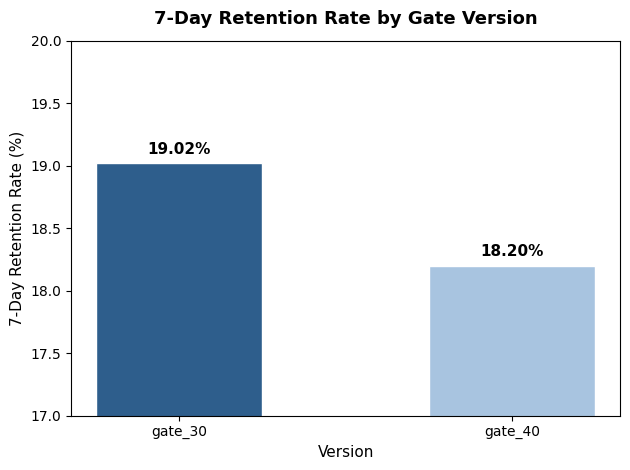

In [14]:
import matplotlib.pyplot as plt

retention_rates = (
    df.groupby('version')['retention_7']
    .mean()
    .mul(100)
    .reset_index()
)

colors = ['#2E5E8C', '#A8C4E0']
bars = plt.bar(
    retention_rates['version'],
    retention_rates['retention_7'],
    color=colors,
    width=0.5,
    edgecolor='white'
)

for bar, val in zip(bars, retention_rates['retention_7']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{val:.2f}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.title('7-Day Retention Rate by Gate Version', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Version', fontsize=11)
plt.ylabel('7-Day Retention Rate (%)', fontsize=11)
plt.ylim(17, 20)
plt.tight_layout()
plt.show()

## Summary & Recommendation

| Test | Metric | Result | p-value |
|------|--------|--------|---------|
| Welch's t-test | Game rounds played (guardrail) | No significant difference | 0.3759 |
| Two-proportion z-test | 1-day retention | No significant difference | 0.0744 |
| Two-proportion z-test | 7-day retention | Significant — gate_30 higher | 0.0016 |

The guardrail metric (game rounds played) shows no significant difference between groups, confirming the gate change did not affect overall engagement volume. 1-day retention was not significantly affected by gate placement. However, 7-day retention was significantly lower in the gate_40 group (p = 0.0016), indicating that placing the gate earlier at level 30 is associated with stronger long-term player retention.

**Recommendation: retain the gate at level 30.** The data does not support moving the gate to level 40. The enforced break at level 30 appears to support habit formation in a way that keeps players returning over a longer time horizon.

*Note: a small sample ratio mismatch was detected (p = 0.0086). Results should be interpreted with this caveat and the randomization mechanism reviewed before acting on findings in a production setting.*